In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
reg  = pd.read_csv('anonymisedData/studentRegistration.csv')
info = pd.read_csv('anonymisedData/studentInfo.csv')
vle  = pd.read_csv('anonymisedData/vle.csv')
svle = pd.read_csv('anonymisedData/studentVle.csv')

In [3]:
for name, df in [('studentRegistration', reg), ('studentInfo', info),
                  ('vle', vle), ('studentVle', svle)]:
    print(f'{name}shape: {df.shape}')
    print(df.head(3))

studentRegistrationshape: (32593, 5)
  code_module code_presentation  id_student  date_registration  \
0         AAA             2013J       11391             -159.0   
1         AAA             2013J       28400              -53.0   
2         AAA             2013J       30268              -92.0   

   date_unregistration  
0                  NaN  
1                  NaN  
2                 12.0  
studentInfoshape: (32593, 12)
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                 

In [12]:
for name, df in [('studentRegistration', reg), ('studentInfo', info),
                  ('vle', vle), ('studentVle', svle)]:
    #print(df.isnull().sum())
    print( df.isnull().sum()/ len(df) * 100)

code_module             0.000000
code_presentation       0.000000
id_student              0.000000
date_registration       0.138066
date_unregistration    69.097659
dtype: float64
code_module             0.000000
code_presentation       0.000000
id_student              0.000000
gender                  0.000000
region                  0.000000
highest_education       0.000000
imd_band                3.408707
age_band                0.000000
num_of_prev_attempts    0.000000
studied_credits         0.000000
disability              0.000000
final_result            0.000000
dtype: float64
id_site               0.000000
code_module           0.000000
code_presentation     0.000000
activity_type         0.000000
week_from            82.385292
week_to              82.385292
dtype: float64
code_module          0.0
code_presentation    0.0
id_student           0.0
id_site              0.0
date                 0.0
sum_click            0.0
dtype: float64


In [10]:
for name, df in [('studentRegistration', reg), ('studentInfo', info),
                  ('vle', vle), ('studentVle', svle)]:
        print(f'\n{name}:')
        print(df.describe().round(2))


studentRegistration:
       id_student  date_registration  date_unregistration
count    32593.00           32548.00             10072.00
mean    706687.67             -69.41                49.76
std     549167.31              49.26                82.46
min       3733.00            -322.00              -365.00
25%     508573.00            -100.00                -2.00
50%     590310.00             -57.00                27.00
75%     644453.00             -29.00               109.00
max    2716795.00             167.00               444.00

studentInfo:
       id_student  num_of_prev_attempts  studied_credits
count    32593.00              32593.00         32593.00
mean    706687.67                  0.16            79.76
std     549167.31                  0.48            41.07
min       3733.00                  0.00            30.00
25%     508573.00                  0.00            60.00
50%     590310.00                  0.00            60.00
75%     644453.00                  0.00    

In [8]:
cat_cols = ['gender', 'region', 'highest_education',
            'imd_band', 'age_band', 'disability', 'final_result']
for col in cat_cols:
    if col in info.columns:
        print(f'\n{col}:')
        print(info[col].value_counts(dropna=False))


gender:
gender
M    17875
F    14718
Name: count, dtype: int64

region:
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64

highest_education:
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

imd_band:
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64

age_band:
age_band
0-35     22944
35-55     9

In [11]:
vle['activity_type'].value_counts()

activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
ouelluminate        21
glossary            21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64

In [13]:
reg['date_registration'].describe().round(2)

count    32548.00
mean       -69.41
std         49.26
min       -322.00
25%       -100.00
50%        -57.00
75%        -29.00
max        167.00
Name: date_registration, dtype: float64

In [19]:
n_unreg = reg['date_unregistration'].notna().sum()
print("Students with unregistration date:")
print(n_unreg)

print(n_unreg/len(reg)*100)

Students with unregistration date:
10072
30.902340993464854


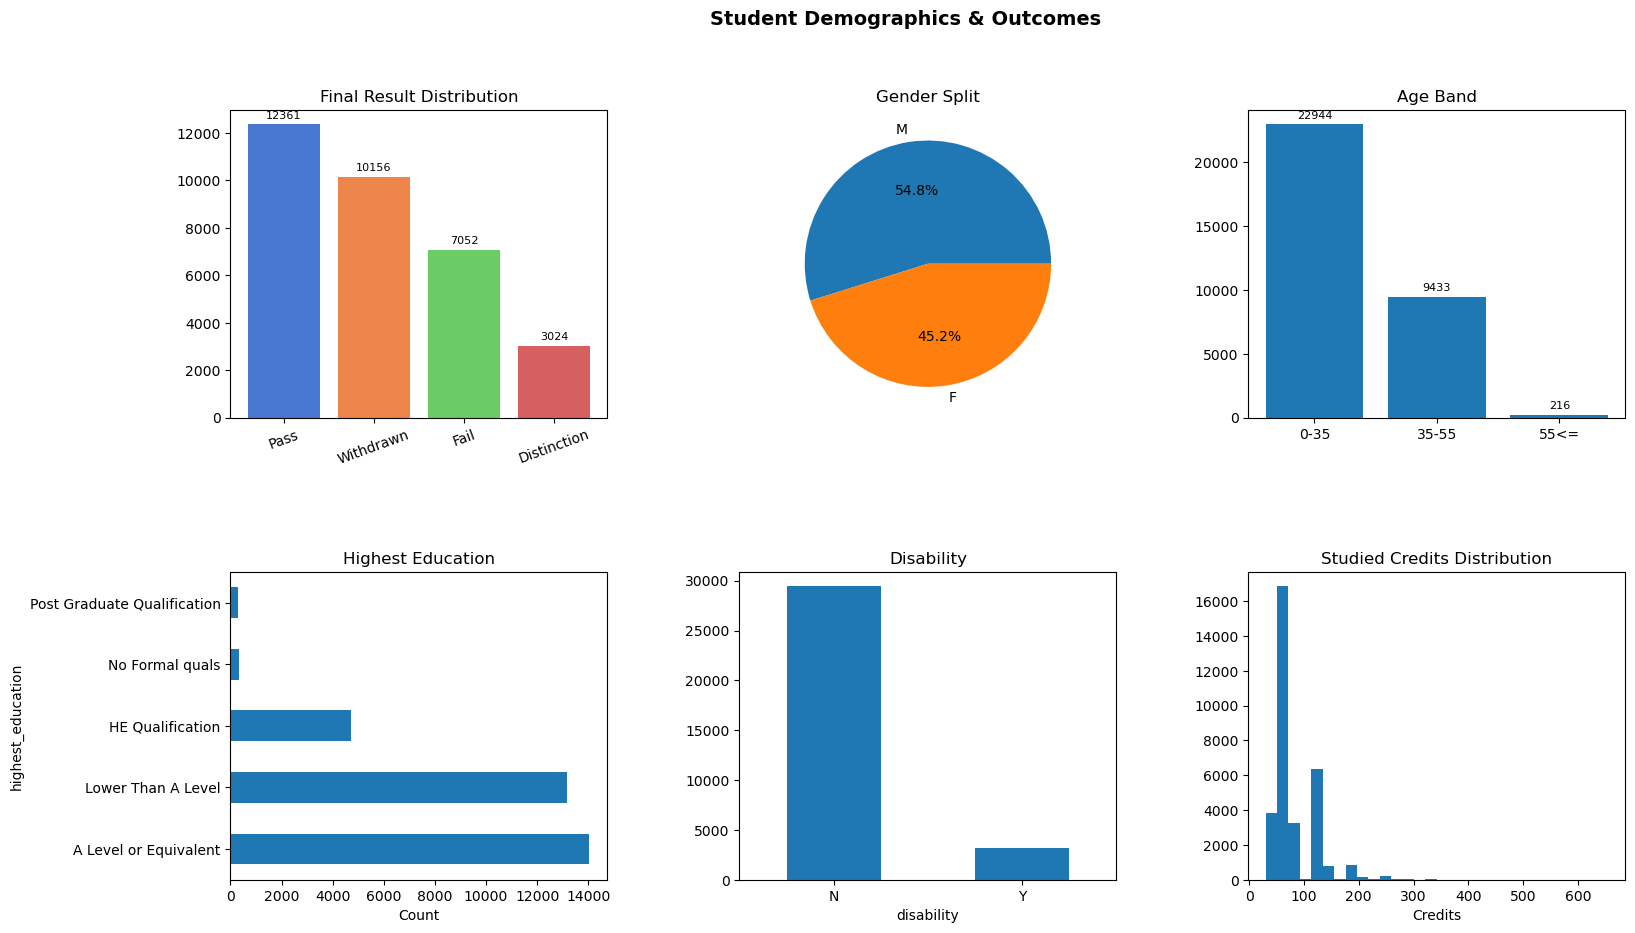

In [22]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Student Demographics & Outcomes', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
vc = info['final_result'].value_counts()
bars = ax1.bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
ax1.bar_label(bars, padding=3, fontsize=8)
ax1.set_title('Final Result Distribution')
ax1.tick_params(axis='x', rotation=20)

ax2 = fig.add_subplot(gs[0, 1])
info['gender'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Gender Split')
ax2.set_ylabel('')

ax3 = fig.add_subplot(gs[0, 2])
age_order = ['0-35', '35-55', '55<=']
vc3 = info['age_band'].value_counts().reindex(age_order, fill_value=0)
bars3 = ax3.bar(vc3.index, vc3.values)
ax3.bar_label(bars3, padding=3, fontsize=8)
ax3.set_title('Age Band')

ax4 = fig.add_subplot(gs[1, 0])
info['highest_education'].value_counts().plot(kind='barh', ax=ax4,)
ax4.set_title('Highest Education')
ax4.set_xlabel('Count')

ax5 = fig.add_subplot(gs[1, 1])
info['disability'].value_counts().plot(kind='bar', ax=ax5,)
ax5.set_title('Disability')
ax5.tick_params(axis='x', rotation=0)

ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(info['studied_credits'].dropna(), bins=30)
ax6.set_title('Studied Credits Distribution')
ax6.set_xlabel('Credits')

plt.show()

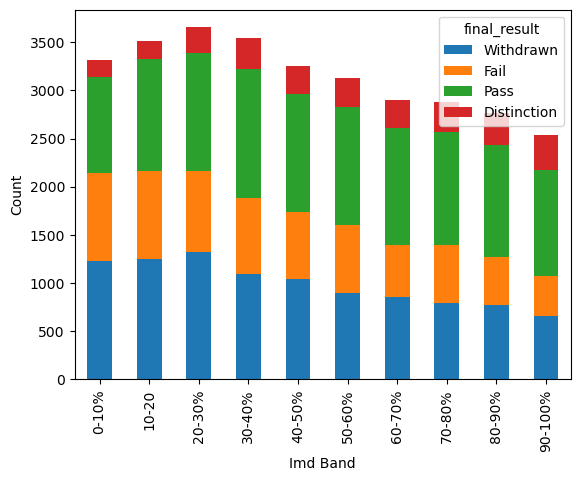

In [25]:
table = pd.crosstab(
    info['imd_band'],info['final_result']
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]
table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Imd Band')
plt.ylabel('Count')
plt.show()

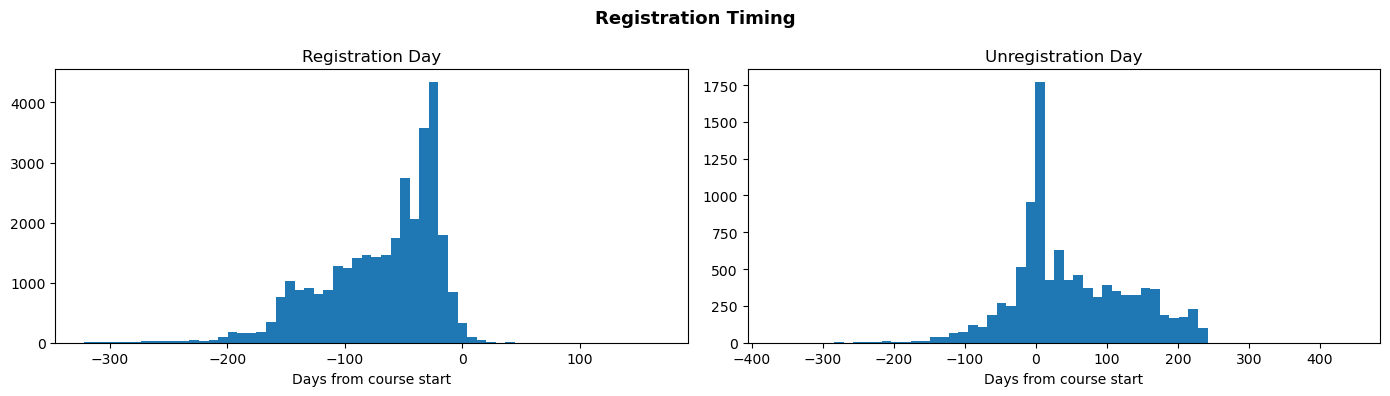

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Registration Timing', fontsize=13, fontweight='bold')

axes[0].hist(reg['date_registration'].dropna(), bins=60)
axes[0].set_title('Registration Day')
#assumption that course starts on day 0
axes[0].set_xlabel('Days from course start')

axes[1].hist(reg['date_unregistration'].dropna(), bins=60)
axes[1].set_title('Unregistration Day')
axes[1].set_xlabel('Days from course start')

plt.tight_layout()
plt.show()

In [35]:
info = info.merge(reg[['id_student', 'code_module', 'code_presentation'] + ['date_registration', 'date_unregistration']],
                  on=['id_student', 'code_module', 'code_presentation'], how='left')
info['registered_late'] = (info['date_registration'] > 0).astype(int)
info['unregistered_early'] = (
    info['date_unregistration'].notna() &
    (info['date_unregistration'] < 262)
).astype(int)

info.drop(columns=['date_registration', 'date_unregistration'], inplace=True)
print(f"  registered_late YES: {info['registered_late'].sum()},  NO: {(info['registered_late']==0).sum()}")
print(f"  unregistered_early YES: {info['unregistered_early'].sum()},  NOP: {(info['unregistered_early']==0).sum()}")

  registered_late YES: 234,  NO: 32359
  unregistered_early YES: 10071,  NOP: 22522


In [36]:
imdo = {'0-10%':0,'10-20':1,'20-30%':2,'30-40%':3,'40-50%':4,
             '50-60%':5,'60-70%':6,'70-80%':7,'80-90%':8,'90-100%':9}
info['imd_band_enc'] = info['imd_band'].map(imdo).fillna(4).astype(int)

eduo = {'No Formal quals': 0, 'Lower Than A Level': 1,
             'A Level or Equivalent': 2, 'HE Qualification': 3,
             'Post Graduate Qualification': 4}
info['education_enc'] = info['highest_education'].map(eduo)

info['num_of_prev_attempts'] = info['num_of_prev_attempts'].fillna(0).astype(int)


In [37]:
info.head(3)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,registered_late,unregistered_early,imd_band_enc,education_enc
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,0,9,3
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,0,2,3
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0,1,3,2
